## Preprocoessing



**Load data**

In [1]:
import numpy as np
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

In [2]:
#Load data 
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "Data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ACCELEROMETER_PATH = PROJECT_ROOT  / "New folder (2)" / "Phones_accelerometer.csv"
GYROSCOPE_PATH = PROJECT_ROOT  / "New folder (2)" / "Phones_gyroscope.csv"
db_accelerometer= pd.read_csv(ACCELEROMETER_PATH)
db_gyroscope= pd.read_csv(GYROSCOPE_PATH)
display(db_accelerometer.head())
display(db_gyroscope.head())

,Index,Arrival_Time,Creation_Time,x,y,z,User,Model,Device,gt
0,0,1424696633908,1424696631913248572,-5.958191,0.688065,8.135345,a,nexus4,nexus4_1,stand
1,1,1424696633909,1424696631918283972,-5.952240,0.670212,8.136536,a,nexus4,nexus4_1,stand
2,2,1424696633918,1424696631923288855,-5.995087,0.653549,8.204376,a,nexus4,nexus4_1,stand
3,3,1424696633919,1424696631928385290,-5.942718,0.676163,8.128204,a,nexus4,nexus4_1,stand
4,4,1424696633929,1424696631933420691,-5.991516,0.641647,8.135345,a,nexus4,nexus4_1,stand


,Index,Arrival_Time,Creation_Time,x,y,z,User,Model,Device,gt
0,0,1424696633909,1424696631914042029,0.013748,-0.000626,-0.023376,a,nexus4,nexus4_1,stand
1,1,1424696633909,1424696631919046912,0.014816,-0.001694,-0.022308,a,nexus4,nexus4_1,stand
2,2,1424696633918,1424696631924051794,0.015884,-0.001694,-0.021240,a,nexus4,nexus4_1,stand
3,3,1424696633919,1424696631929117712,0.016953,-0.003830,-0.020172,a,nexus4,nexus4_1,stand
4,4,1424696633928,1424696631934214148,0.015884,-0.007034,-0.020172,a,nexus4,nexus4_1,stand


Check for null values

In [3]:
print("Null values in db_accelerometer preview:")
print(db_accelerometer.isnull().sum())
print("Null values in db_gyroscope preview:")
print(db_gyroscope.isnull().sum())

Null values in db_accelerometer preview:
Index                  0
Arrival_Time           0
Creation_Time          0
x                      0
y                      0
z                      0
User                   0
Model                  0
Device                 0
gt               1783200
dtype: int64
Null values in db_gyroscope preview:
Index                  0
Arrival_Time           0
Creation_Time          0
x                      0
y                      0
z                      0
User                   0
Model                  0
Device                 0
gt               1869627
dtype: int64


Resolve null values by deleting the rows

In [4]:
db_accelerometer = db_accelerometer[
    db_accelerometer["gt"].notna()
    & (db_accelerometer["gt"].astype(str).str.strip().str.lower() != "null")
].copy()

db_gyroscope = db_gyroscope[
    db_gyroscope["gt"].notna()
    & (db_gyroscope["gt"].astype(str).str.strip().str.lower() != "null")
].copy()


In [5]:
print("Null values in db_accelerometer preview:")
print(db_accelerometer.isnull().sum())
print("Null values in db_gyroscope preview:")
print(db_gyroscope.isnull().sum())

Null values in db_accelerometer preview:
Index            0
Arrival_Time     0
Creation_Time    0
x                0
y                0
z                0
User             0
Model            0
Device           0
gt               0
dtype: int64
Null values in db_gyroscope preview:
Index            0
Arrival_Time     0
Creation_Time    0
x                0
y                0
z                0
User             0
Model            0
Device           0
gt               0
dtype: int64


### No null values :) 
### Now we save the processed data

In [6]:
from pathlib import Path

out_dir = Path("processed")
out_dir.mkdir(parents=True, exist_ok=True)

db_accelerometer.to_csv(out_dir / "phones_accelerometer_clean.csv", index=False)
db_gyroscope.to_csv(out_dir / "phones_gyroscope_clean.csv", index=False)


# Check Class imbalance

Class counts for accelerometer:


,count
gt,
walk,2192401
sit,1991919
stand,1851492
bike,1845557
stairsup,1782010
stairsdown,1615896


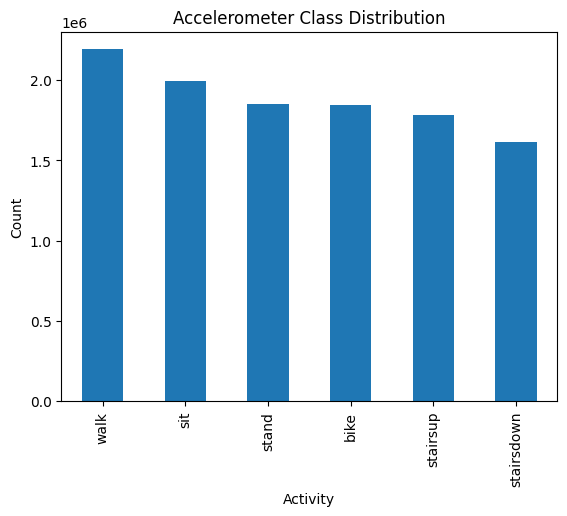

Class counts for gyroscope:


,count
gt,
walk,2350429
sit,2218501
stand,2024206
bike,1911730
stairsup,1884306
stairsdown,1673833


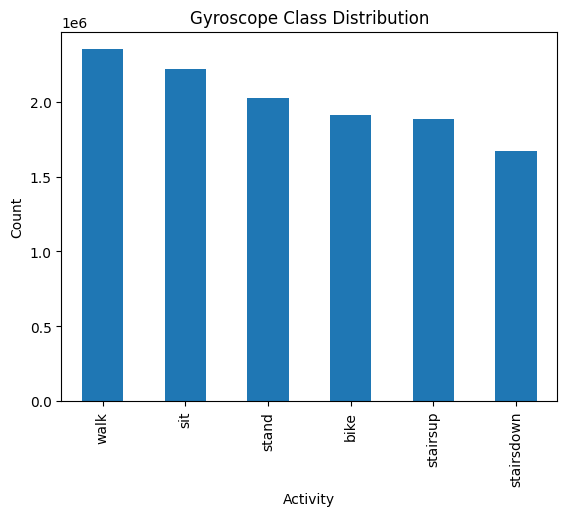

In [7]:
# Check class imbalance for accelerometer data
acc_class_counts = db_accelerometer['gt'].value_counts()
print("Class counts for accelerometer:")
display(acc_class_counts.to_frame())

# Plot
acc_class_counts.plot(kind='bar', title='Accelerometer Class Distribution')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.show()

# Check class imbalance for gyroscope data
gyro_class_counts = db_gyroscope['gt'].value_counts()
print("Class counts for gyroscope:")
display(gyro_class_counts.to_frame())

# Plot
gyro_class_counts.plot(kind='bar', title='Gyroscope Class Distribution')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.show()

In [8]:
# Count users for accelerometer data
acc_user_counts = db_accelerometer['User'].value_counts()
print("User counts for accelerometer:")
display(acc_user_counts.to_frame())

# Count users for gyroscope data
gyro_user_counts = db_gyroscope['User'].value_counts()
print("User counts for gyroscope:")
display(gyro_user_counts.to_frame())

User counts for accelerometer:


,count
User,
i,1342007
b,1320280
e,1310856
g,1278593
d,1223857
h,1223093
a,1218871
c,1188186
f,1173532


User counts for gyroscope:


,count
User,
i,1453955
e,1422338
b,1420750
g,1387361
d,1331326
a,1329103
h,1322948
c,1282412
f,1112812


Classes are balanced we good :)

# Windowing 
#### 1-For windowing we need to first sort it by time and user since it is a time serires 
#### 2- Segment them per user
#### 3- For each user we window that 

In [9]:
# Sort by User and Creation_Time and reset index for stable segmenting
db_accelerometer = db_accelerometer.sort_values(by=['User', 'Creation_Time']).reset_index(drop=True)
db_gyroscope = db_gyroscope.sort_values(by=['User', 'Creation_Time']).reset_index(drop=True)


In [10]:
from collections import Counter

# Window settings
Window_size = 100
Window_stride = 50


def smooth_sensor_per_user(df, sensor_cols=('x', 'y', 'z'), user_col='User', window=5):
    """
    Apply a light rolling-mean smoothing per user.
    This is especially useful for gyroscope noise reduction.
    """
    df = df.copy()
    for col in sensor_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=list(sensor_cols)).copy()

    for col in sensor_cols:
        df[col] = (
            df.groupby(user_col)[col]
              .transform(lambda s: s.rolling(window=window, center=True, min_periods=1).mean())
        )

    return df


# Light signal smoothing before segmentation
# Accelerometer gets mild smoothing; gyroscope benefits more from it.
db_accelerometer = smooth_sensor_per_user(db_accelerometer, window=3)
db_gyroscope = smooth_sensor_per_user(db_gyroscope, window=5)


def segment_har(
    df,
    window_size=100,
    stride=50,
    sensor_cols=('x', 'y', 'z'),
    user_col='User',
    time_col='Creation_Time',
    label_col='gt',
    min_label_ratio=1.0,
):

    windows = []
    labels = []

    df = df.sort_values([user_col, time_col]).copy()

    for user, user_df in df.groupby(user_col, sort=False):
        user_df = user_df.sort_values(time_col).copy()

        # Create consecutive label runs so windows never mix different activities.
        run_id = (user_df[label_col] != user_df[label_col].shift()).cumsum()
        user_df['_run_id'] = run_id

        for _, seg_df in user_df.groupby('_run_id', sort=False):
            seg_df = seg_df.sort_values(time_col)
            seg_label = seg_df[label_col].iloc[0]
            arr = seg_df[list(sensor_cols)].to_numpy(dtype=np.float32)
            seg_labels = seg_df[label_col].to_numpy()

            if len(arr) < window_size:
                continue

            for start in range(0, len(arr) - window_size + 1, stride):
                end = start + window_size
                chunk = arr[start:end]
                chunk_labels = seg_labels[start:end]
                majority_label, majority_count = Counter(chunk_labels).most_common(1)[0]
                purity = majority_count / len(chunk_labels)

                if purity < min_label_ratio:
                    continue

                windows.append(chunk)
                labels.append(majority_label)

    if not windows:
        X = np.empty((0, window_size, len(sensor_cols)), dtype=np.float32)
        y = np.empty((0,), dtype=object)
    else:
        X = np.stack(windows).astype(np.float32)
        y = np.array(labels)

    return X, y


# apply to accelerometer data
X_acc, y_acc = segment_har(
    db_accelerometer,
    window_size=Window_size,
    stride=Window_stride,
    min_label_ratio=1.0,
)

print('X_acc shape:', X_acc.shape)
print('y_acc shape:', y_acc.shape)
print('Sample label distribution:')
print(pd.Series(y_acc).value_counts())


X_acc shape: (212772, 100, 3)
y_acc shape: (212772,)
Sample label distribution:
walk          43532
sit           38547
stairsup      34725
stand         32953
bike          31640
stairsdown    31375
Name: count, dtype: int64


In [11]:
# apply to gyroscope data
X_gyro, y_gyro = segment_har(
    db_gyroscope,
    window_size=Window_size,
    stride=Window_stride,
    min_label_ratio=1.0,
)

print('X_gyro shape:', X_gyro.shape)
print('y_gyro shape:', y_gyro.shape)
print('Sample label distribution:')
print(pd.Series(y_gyro).value_counts())


X_gyro shape: (231391, 100, 3)
y_gyro shape: (231391,)
Sample label distribution:
walk          46931
sit           43373
stairsup      37302
stand         36866
bike          33820
stairsdown    33099
Name: count, dtype: int64


### Notes on the updated phone preprocessing

- Gyroscope and accelerometer signals are lightly smoothed before windowing.
- Windows now use 50% overlap (`Window_stride = 50`).
- Windows are created inside consecutive activity runs, so they do not cross label boundaries.
- `min_label_ratio=1.0` keeps only pure-label windows.


# Feature extraction
##### We will be using Nerual Networks for that 

In [12]:
# ===== NN Feature Extraction Helpers (same core structure as Model/Feature_extraction.ipynb, cleaned) =====

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility + device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def encode_labels(y):
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(np.asarray(y))
    return y_encoded.astype(np.int64), encoder


def split_data(X, y_encoded, test_size=0.20, valid_size=0.20, random_state=SEED):
    idx = np.arange(len(X))

    train_idx, test_idx = train_test_split(
        idx, test_size=test_size, random_state=random_state, stratify=y_encoded
    )

    train_idx, valid_idx = train_test_split(
        train_idx, test_size=valid_size, random_state=random_state, stratify=y_encoded[train_idx]
    )

    splits = {}
    for name, split_idx in {"train": train_idx, "valid": valid_idx, "test": test_idx}.items():
        splits[name] = {"X": X[split_idx], "y": y_encoded[split_idx]}
    return splits


def scale_windows(train_X, valid_X, test_X):
    scaler = StandardScaler()
    n_channels = train_X.shape[-1]

    train_flat = train_X.reshape(-1, n_channels)
    valid_flat = valid_X.reshape(-1, n_channels)
    test_flat = test_X.reshape(-1, n_channels)

    train_scaled = scaler.fit_transform(train_flat).reshape(train_X.shape).astype(np.float32)
    valid_scaled = scaler.transform(valid_flat).reshape(valid_X.shape).astype(np.float32)
    test_scaled = scaler.transform(test_flat).reshape(test_X.shape).astype(np.float32)

    return train_scaled, valid_scaled, test_scaled, scaler


def flatten_windows(X):
    return X.reshape(X.shape[0], -1).astype(np.float32)


class SimpleFeatureExtractor(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims=(128, 64)):
        super().__init__()
        self.hidden_layers = nn.ModuleList()
        prev_dim = input_dim
        for h in hidden_dims:
            self.hidden_layers.append(nn.Linear(prev_dim, h))
            prev_dim = h
        self.output_layer = nn.Linear(prev_dim, num_classes)

    def forward_features(self, x):
        for layer in self.hidden_layers:
            x = torch.relu(layer(x))
        return x

    def forward(self, x):
        features = self.forward_features(x)
        return self.output_layer(features)


def make_loader(X, y, batch_size=256, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_loader, valid_loader, epochs=8, learning_rate=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses, train_true, train_pred = [], [], []

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            train_true.extend(yb.detach().cpu().numpy())
            train_pred.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())

        model.eval()
        valid_losses, valid_true, valid_pred = [], [], []

        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)

                valid_losses.append(loss.item())
                valid_true.extend(yb.detach().cpu().numpy())
                valid_pred.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())

        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(train_losses)),
                "valid_loss": float(np.mean(valid_losses)),
                "train_accuracy": float(accuracy_score(train_true, train_pred)),
                "valid_accuracy": float(accuracy_score(valid_true, valid_pred)),
            }
        )

    return pd.DataFrame(history)


def extract_hidden_features(model, X_flat, batch_size=512):
    model.eval()
    feats = []
    loader = DataLoader(torch.tensor(X_flat, dtype=torch.float32), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            batch_feats = model.forward_features(xb)
            feats.append(batch_feats.cpu().numpy())
    return np.vstack(feats).astype(np.float32)


def predict_classes(model, X_flat, batch_size=512):
    model.eval()
    preds = []
    loader = DataLoader(torch.tensor(X_flat, dtype=torch.float32), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            preds.append(torch.argmax(logits, dim=1).cpu().numpy())
    return np.concatenate(preds)


def run_feature_extraction_from_windows(
    X_windows,
    y_labels,
    hidden_dims=(128, 64),
    batch_size=256,
    epochs=8,
    learning_rate=1e-3,
):
    # X_windows must be shape: (num_windows, window_size, num_channels)
    if X_windows.ndim != 3:
        raise ValueError(f"Expected 3D X_windows, got shape {X_windows.shape}")

    y_encoded, encoder = encode_labels(y_labels)
    splits = split_data(X_windows, y_encoded)

    X_train, X_valid, X_test, scaler = scale_windows(
        splits["train"]["X"], splits["valid"]["X"], splits["test"]["X"]
    )

    X_train_flat = flatten_windows(X_train)
    X_valid_flat = flatten_windows(X_valid)
    X_test_flat = flatten_windows(X_test)

    model = SimpleFeatureExtractor(
        input_dim=X_train_flat.shape[1],
        num_classes=len(encoder.classes_),
        hidden_dims=hidden_dims,
    ).to(DEVICE)

    train_loader = make_loader(X_train_flat, splits["train"]["y"], batch_size=batch_size, shuffle=True)
    valid_loader = make_loader(X_valid_flat, splits["valid"]["y"], batch_size=batch_size, shuffle=False)

    history_df = train_model(
        model=model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        epochs=epochs,
        learning_rate=learning_rate,
    )

    X_train_feat = extract_hidden_features(model, X_train_flat)
    X_valid_feat = extract_hidden_features(model, X_valid_flat)
    X_test_feat = extract_hidden_features(model, X_test_flat)

    y_train_pred = predict_classes(model, X_train_flat)
    y_valid_pred = predict_classes(model, X_valid_flat)
    y_test_pred = predict_classes(model, X_test_flat)

    print("Window input shape:", X_windows.shape)
    print("Train flattened shape:", X_train_flat.shape)
    print("Feature shapes:", X_train_feat.shape, X_valid_feat.shape, X_test_feat.shape)
    print(f"NN Train Accuracy: {accuracy_score(splits['train']['y'], y_train_pred):.4f}")
    print(f"NN Valid Accuracy: {accuracy_score(splits['valid']['y'], y_valid_pred):.4f}")
    print(f"NN Test  Accuracy: {accuracy_score(splits['test']['y'], y_test_pred):.4f}")

    return {
        "model": model,
        "history": history_df,
        "label_encoder": encoder,
        "scaler": scaler,
        "splits": splits,

        "X_train_flat": X_train_flat,
        "X_valid_flat": X_valid_flat,
        "X_test_flat": X_test_flat,

        "X_train_feat": X_train_feat,
        "X_valid_feat": X_valid_feat,
        "X_test_feat": X_test_feat,

        "y_train": splits["train"]["y"],
        "y_valid": splits["valid"]["y"],
        "y_test": splits["test"]["y"],
    }


In [13]:
# Extract features for gyroscope data
gyro_out = run_feature_extraction_from_windows(
    X_windows=X_gyro,
    y_labels=y_gyro,
    hidden_dims=(128, 64),
    batch_size=256,
    epochs=8,
    learning_rate=1e-3,
)

# full extracted features + labels 
gyro_features = np.vstack([
    gyro_out["X_train_feat"],
    gyro_out["X_valid_feat"],
    gyro_out["X_test_feat"],
])
gyro_labels = np.concatenate([
    gyro_out["y_train"],
    gyro_out["y_valid"],
    gyro_out["y_test"],
])

print("gyro_features:", gyro_features.shape)
print("gyro_labels:", gyro_labels.shape)


Window input shape: (231391, 100, 3)
Train flattened shape: (148089, 300)
Feature shapes: (148089, 64) (37023, 64) (46279, 64)
NN Train Accuracy: 0.8461
NN Valid Accuracy: 0.8336
NN Test  Accuracy: 0.8341
gyro_features: (231391, 64)
gyro_labels: (231391,)


In [14]:
# Extract features for accelerometer data
acc_out = run_feature_extraction_from_windows(
    X_windows=X_acc,
    y_labels=y_acc,
    hidden_dims=(128, 64),
    batch_size=256,
    epochs=8,
    learning_rate=1e-3,
)

# full extracted features 
acc_features = np.vstack([
    acc_out["X_train_feat"],
    acc_out["X_valid_feat"],
    acc_out["X_test_feat"],
])
acc_labels = np.concatenate([
    acc_out["y_train"],
    acc_out["y_valid"],
    acc_out["y_test"],
])

print("acc_features:", acc_features.shape)
print("acc_labels:", acc_labels.shape)


Window input shape: (212772, 100, 3)
Train flattened shape: (136173, 300)
Feature shapes: (136173, 64) (34044, 64) (42555, 64)
NN Train Accuracy: 0.9436
NN Valid Accuracy: 0.9292
NN Test  Accuracy: 0.9294
acc_features: (212772, 64)
acc_labels: (212772,)


In [15]:

from pathlib import Path
import numpy as np

out_dir = Path()
out_dir.mkdir(parents=True, exist_ok=True)

np.savez(out_dir / "acc_features_full.npz", features=acc_features, labels=acc_labels)
np.savez(out_dir / "gyro_features_full.npz", features=gyro_features, labels=gyro_labels)

print("Saved:")
print(out_dir / "acc_features_full.npz")
print(out_dir / "gyro_features_full.npz")


Saved:
acc_features_full.npz
gyro_features_full.npz


In [18]:

from sklearn.metrics import accuracy_score, classification_report
import torch
from torch.utils.data import DataLoader

def predict_classes(model, X_flat, batch_size=512):
    model.eval()
    preds = []
    loader = DataLoader(torch.tensor(X_flat, dtype=torch.float32), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            preds.append(torch.argmax(logits, dim=1).cpu().numpy())
    return np.concatenate(preds)

def evaluate_split(name, model, X_flat, y_true):
    y_pred = predict_classes(model, X_flat)
    acc = accuracy_score(y_true, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    return y_pred


In [19]:
print("=== ACCELEROMETER NN RESULTS ===")
gyro_train_pred = evaluate_split("Train", acc_out["model"], acc_out["X_train_flat"], acc_out["y_train"])
gyro_valid_pred = evaluate_split("Valid", acc_out["model"], acc_out["X_valid_flat"], acc_out["y_valid"])
gyro_test_pred  = evaluate_split("Test",  acc_out["model"], acc_out["X_test_flat"],  acc_out["y_test"])

print("\nGyro Test Classification Report:")
print(classification_report(acc_out["y_test"], gyro_test_pred, zero_division=0))

=== ACCELEROMETER NN RESULTS ===
Train Accuracy: 0.9436
Valid Accuracy: 0.9292
Test Accuracy: 0.9294

Gyro Test Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      6328
           1       0.98      0.99      0.99      7709
           2       0.89      0.83      0.86      6275
           3       0.86      0.90      0.88      6945
           4       0.97      0.98      0.97      6591
           5       0.93      0.92      0.93      8707

    accuracy                           0.93     42555
   macro avg       0.93      0.93      0.93     42555
weighted avg       0.93      0.93      0.93     42555



In [17]:

print("=== GYROSCOPE NN RESULTS ===")
gyro_train_pred = evaluate_split("Train", gyro_out["model"], gyro_out["X_train_flat"], gyro_out["y_train"])
gyro_valid_pred = evaluate_split("Valid", gyro_out["model"], gyro_out["X_valid_flat"], gyro_out["y_valid"])
gyro_test_pred  = evaluate_split("Test",  gyro_out["model"], gyro_out["X_test_flat"],  gyro_out["y_test"])

print("\nGyro Test Classification Report:")
print(classification_report(gyro_out["y_test"], gyro_test_pred, zero_division=0))


=== GYROSCOPE NN RESULTS ===
Train Accuracy: 0.8461
Valid Accuracy: 0.8336
Test Accuracy: 0.8341

Gyro Test Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      6764
           1       0.75      0.83      0.79      8675
           2       0.81      0.86      0.83      6620
           3       0.84      0.90      0.87      7461
           4       0.75      0.67      0.71      7373
           5       0.95      0.89      0.92      9386

    accuracy                           0.83     46279
   macro avg       0.83      0.83      0.83     46279
weighted avg       0.84      0.83      0.83     46279

